# House Price Prediction

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats



In [2]:
df=pd.read_csv("..\Data\data.csv")
print(f"rows {df.shape[0]},Columns {df.shape[1]}")
df.head()


rows 1460,Columns 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



# Task 1: Complete Data Analysis Report


## Structure of the Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# Finding Missing Values

In [5]:
feature_dict = pd.DataFrame({
    #"Feature": df.columns,
    "Data Type": df.dtypes.values,
    "count":df.count().values,
    "nullvalues":(df.isnull().sum().values)>0,
    'Missing %': (df.isnull().sum()/len(df))*100
})

feature_dict

,Data Type,count,nullvalues,Missing %
Id,int64,1460,False,0.000000
MSSubClass,int64,1460,False,0.000000
MSZoning,object,1460,False,0.000000
LotFrontage,float64,1201,True,17.739726
LotArea,int64,1460,False,0.000000
...,...,...,...,...
MoSold,int64,1460,False,0.000000
YrSold,int64,1460,False,0.000000
SaleType,object,1460,False,0.000000
SaleCondition,object,1460,False,0.000000


In [6]:
missing_values = pd.DataFrame({
    "Null Values": df.isnull().sum(),
    "Missing %": ((df.isnull().sum() / len(df)) * 100).round(2)
})

missing_values = missing_values[missing_values["Null Values"] > 0]

missing_values

,Null Values,Missing %
LotFrontage,259,17.74
Alley,1369,93.77
MasVnrType,872,59.73
MasVnrArea,8,0.55
BsmtQual,37,2.53
BsmtCond,37,2.53
BsmtExposure,38,2.60
BsmtFinType1,37,2.53
BsmtFinType2,38,2.60
Electrical,1,0.07


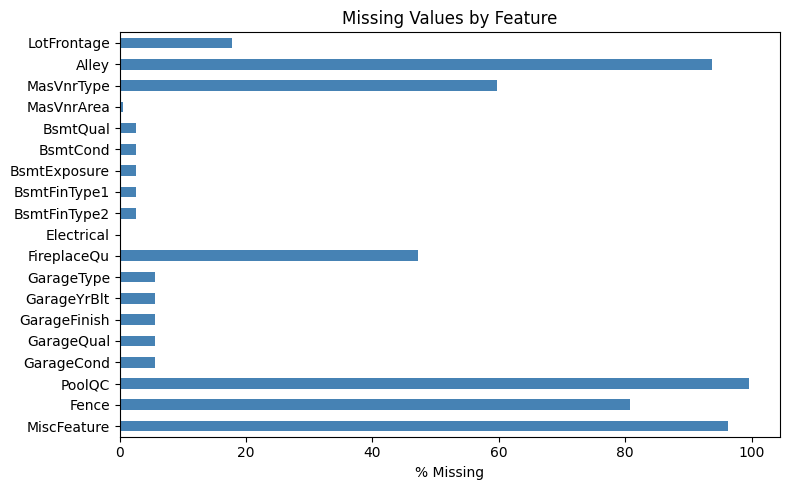

In [7]:
fig,ax=plt.subplots(figsize=(8,5))
missing_values['Missing %'].plot(kind='barh',ax=ax,color='steelblue')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Feature')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Observations:**
- `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu` have very high missing rates (>47%). Per the data dictionary, `NA` in these columns does **not** mean missing data — it means the house does not have that feature (e.g. no pool, no fence, no fireplace). These will be encoded as a `'None'` category rather than imputed statistically.
- `LotFrontage` (~17.7% missing) is a genuinely unobserved measurement and needs numeric imputation.
- Garage-related and basement-related columns are missing together in the same rows (houses without a garage/basement), confirming the "NA = absence of feature" pattern.
- `Electrical` has a single missing value, safely filled with the mode.

## Target Variable: SalePrice

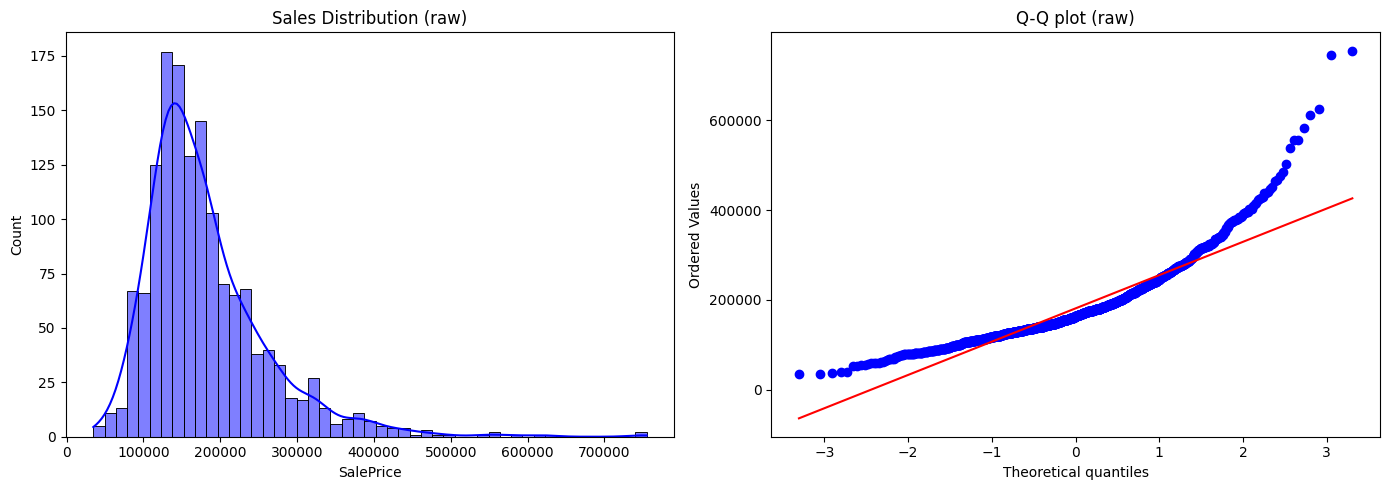

skewness:1.8828757597682129
curtsis:6.536281860064529


In [8]:
fig,axis=plt.subplots(1,2,figsize=(14,5))
sns.histplot(df['SalePrice'],kde=True, ax=axis[0],color='blue')
axis[0].set_title("Sales Distribution (raw)")
stats.probplot(df['SalePrice'],plot=axis[1])
axis[1].set_title("Q-Q plot (raw)")
plt.tight_layout()
plt.show()
print(f"skewness:{df['SalePrice'].skew()}")
print(f"curtsis:{df['SalePrice'].kurt()}")

**Observations:**
- skewness:1.8828757597682129
* The distribution is positively skewed (right tail) .
- curtsis:6.536281860064529
* There are many extreme values/outliers.
* typical of price data with a long tail of expensive homes. A `log1p` transform makes it approximately normal 

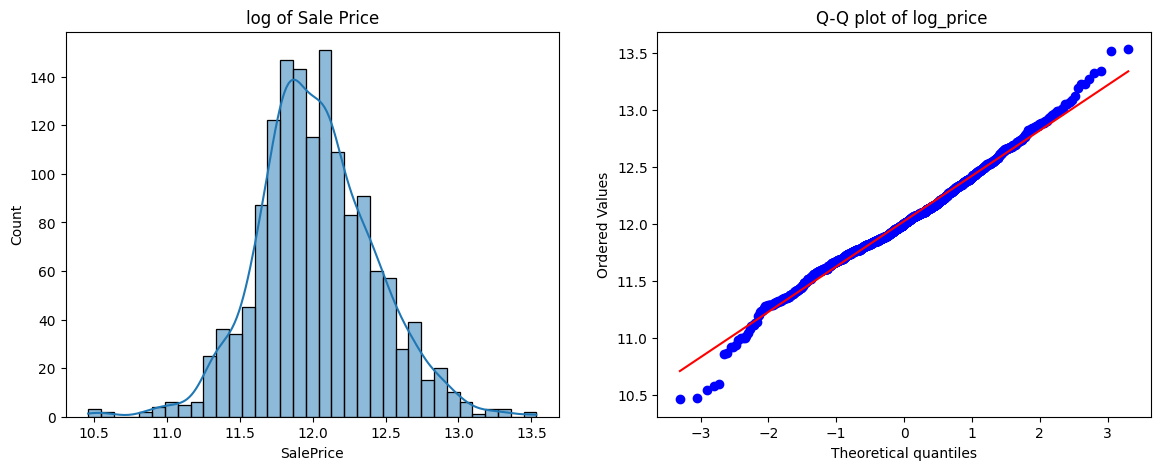

skewness :0.121
kurtosis :0.810


In [9]:
log_price=np.log1p(df['SalePrice'])
fig,axis=plt.subplots(1,2,figsize=[14,5])
sns.histplot(log_price,kde=True,ax=axis[0])
stats.probplot(log_price,plot=axis[1])
axis[0].set_title("log of Sale Price")
axis[1].set_title("Q-Q plot of log_price ")
plt.show()
print(f"skewness :{log_price.skew():.3f}")
print(f'kurtosis :{log_price.kurt():.3f}')


- skewness :`-0.063`
- kurtosis :`0.940`
* These values are much closer to a normal distribution, which is often beneficial for statistical analysis and some machine learning models.

# Correlations with SalePrice

In [48]:
num_cols=df.select_dtypes(include=np.number)
corr=num_cols.corr()['SalePrice']
corr.drop('SalePrice').head(15)
top_corr_features = corr.drop('SalePrice').abs().sort_values(ascending=False).head(15).index
top_corr_features

Index(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
       '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd',
       'GarageYrBlt', 'MasVnrArea', 'Fireplaces', 'BsmtFinSF1', 'LotFrontage'],
      dtype='object')

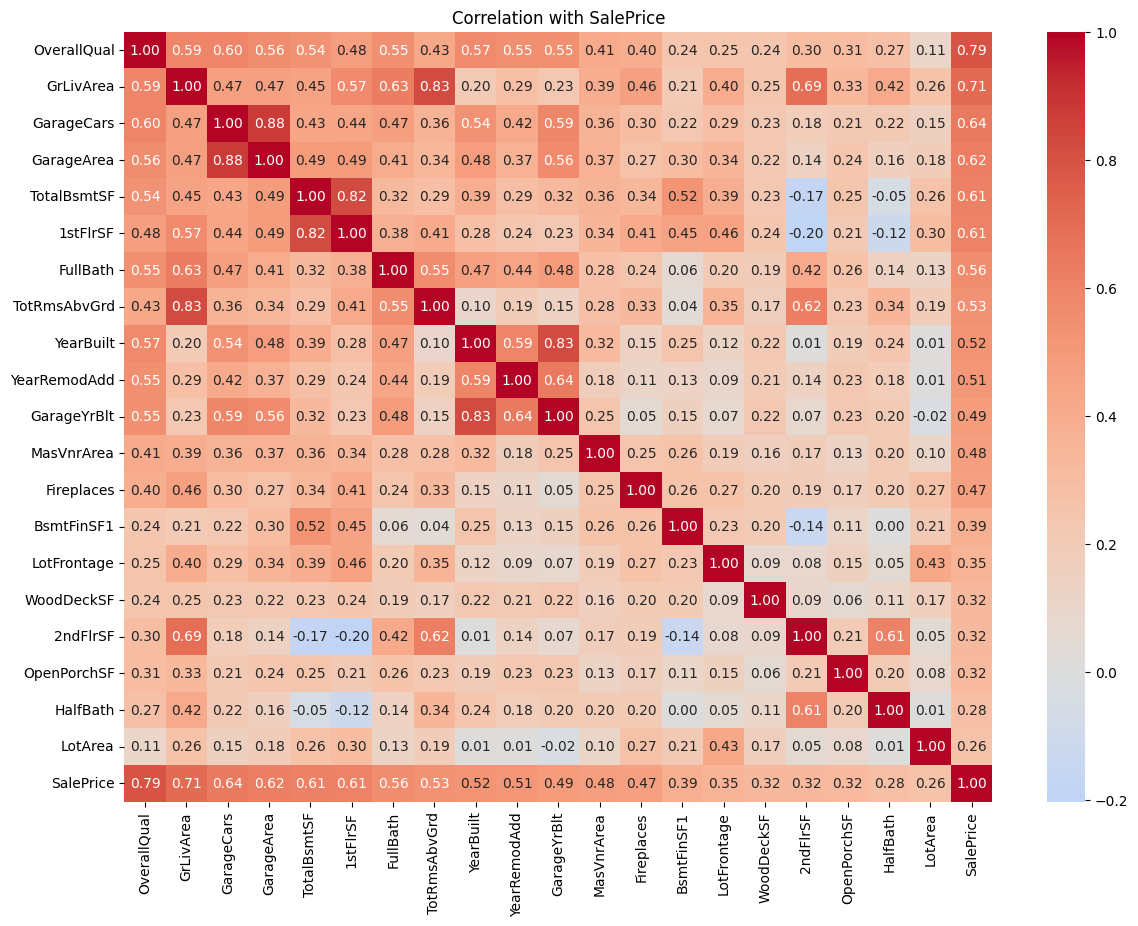

In [47]:
plt.figure(figsize=(14,10))
sns.heatmap(num_cols[list(top_corr_features) + ['SalePrice']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation with SalePrice')
plt.show()


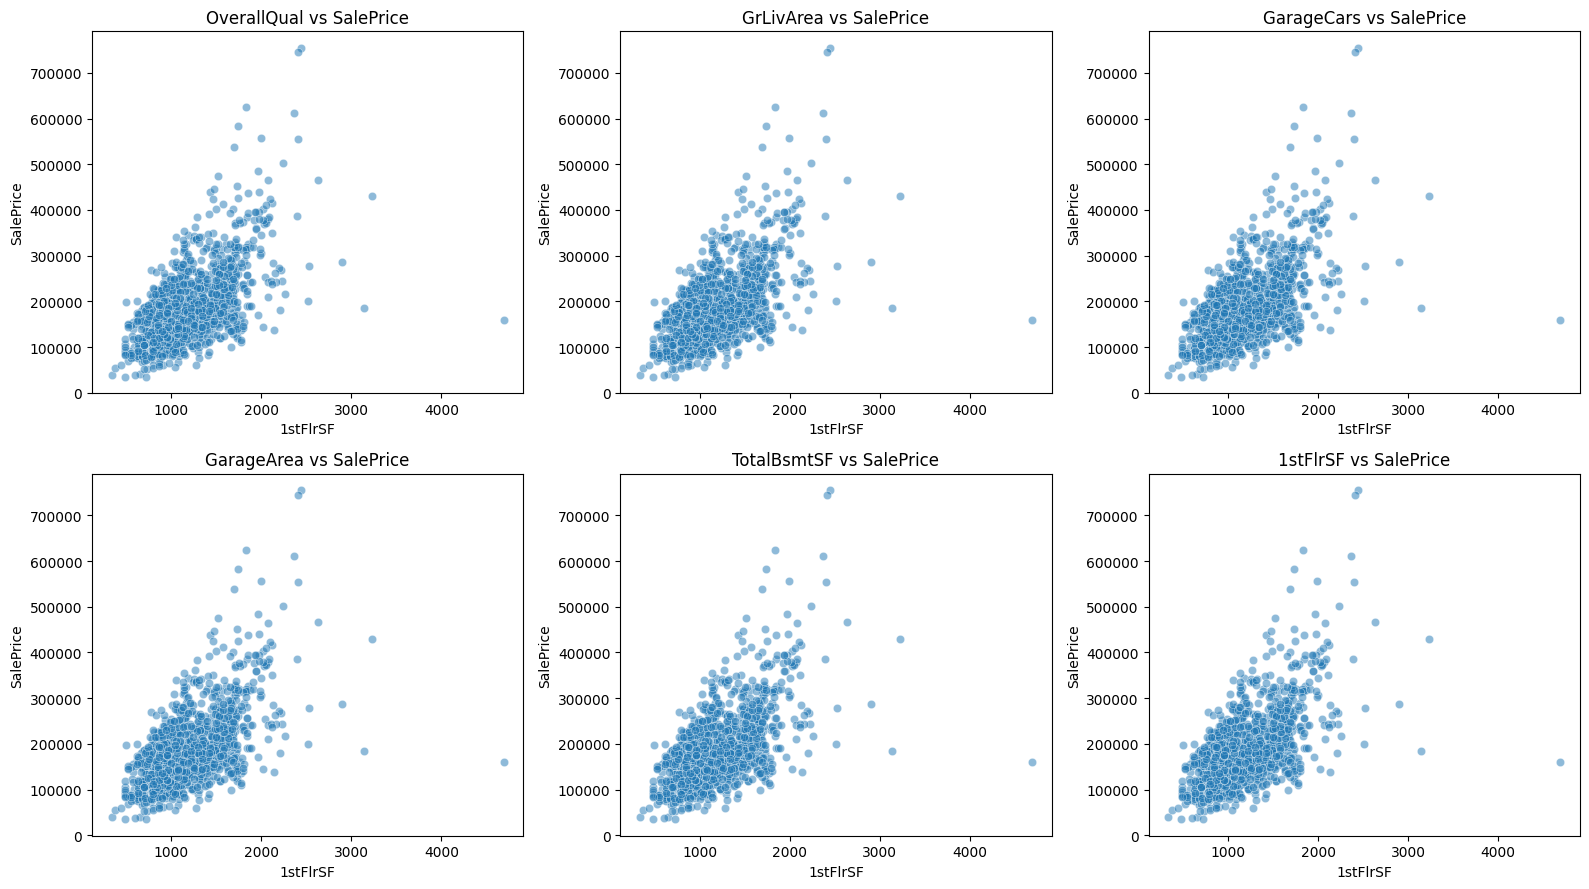

In [26]:
fig,axis=plt.subplots(2,3,figsize=(16,9))
top6 = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF']
for ax, features in zip(axis.flat, top6):
    sns.scatterplot(x=df[feat], y=df['SalePrice'], ax=ax, alpha=0.5)
    ax.set_title(f'{features} vs SalePrice')
plt.tight_layout()
plt.show()

**Observations:**
- `OverallQual` (material/finish quality rating) is the single strongest predictor of price.
- Living-area size measures (`GrLivArea`, `TotalBsmtSF`, `1stFlrSF`) and garage capacity (`GarageCars`, `GarageArea`) are all strongly positively correlated with price — bigger, higher-capacity houses sell for more, as expected.
- A couple of large `GrLivArea` outliers with disproportionately low price are visible — these are known "sale condition" outliers in the Ames dataset and are addressed in the cleaning step below.

# Categorical Features vs SalePrice

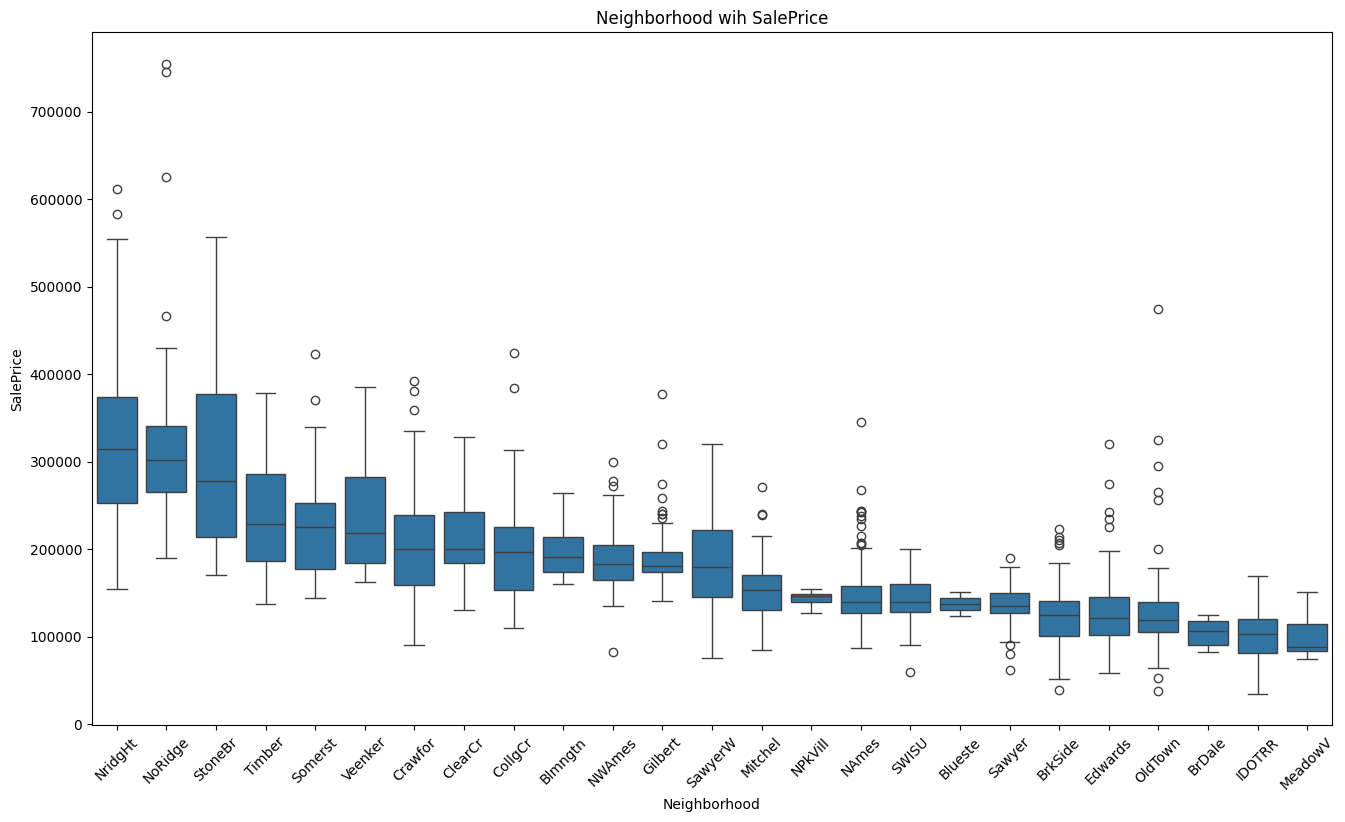

In [44]:
fig=plt.subplots(figsize=(16,9))
group=df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
sns.boxplot(data=df,x='Neighborhood',y='SalePrice',order=group)
plt.tick_params(axis='x',rotation=45)
plt.title('Neighborhood wih SalePrice')
plt.show()


**Observation:** Price varies enormously by `Neighborhood` (median prices range roughly 3-4x between the cheapest and most expensive areas), confirming location as a major price driver alongside physical house attributes.

# Data Preprocessing & Feature Engineering